# Asymmetric VAR Directional Risk Network

This notebook replaces the conceptual placeholder scores with estimates from the project data. Rows are **risk givers** and columns are **risk receivers**. Each cell is the percentage of the receiver's three-month-ahead forecast-error variance attributed to innovations in the giver.

## Method

1. Convert all series to monthly stress-oriented signals, where a positive value represents adverse news.
2. Split each signal into bad-news magnitude $\max(s_t,0)$ and good-news magnitude $\max(-s_t,0)$.
3. Estimate a separate bivariate VAR(1) for every giver–receiver pair. Pairwise VARs preserve the longest available history because ETF and tokenized-fund series begin later than the other data.
4. Calculate an order-invariant generalized forecast-error variance decomposition (GFEVD) at a three-month horizon and report the directional share **giver → receiver**.

The framework follows [Diebold and Yilmaz (2012)](https://doi.org/10.1016/j.ijforecast.2011.02.006) and the good/bad asymmetry idea in [Baruník, Kočenda and Vácha](https://arxiv.org/abs/1308.1221). These are predictive connectedness estimates, not causal effects.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.tsa.api import VAR

ROOT = Path('.')
OUTPUT_FOLDER = ROOT / 'VAR_Network_Output'
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold', 'font.size': 10})

def read_time_csv(path, date_column='Date'):
    frame = pd.read_csv(path)
    frame[date_column] = pd.to_datetime(frame[date_column], errors='coerce', utc=True).dt.tz_localize(None)
    return frame.dropna(subset=[date_column]).sort_values(date_column)

def monthly_last(series):
    return series.sort_index().resample('ME').last()

def monthly_sum(series):
    return series.sort_index().resample('ME').sum(min_count=1)


## 1. Construct stress-oriented giver signals

A positive signal always means worsening conditions: burns, movement below the peg, rising redemption pressure, negative crypto returns, ETF outflows, or falling tokenized-fund market capitalization.

In [2]:
A = ROOT / 'Panel_A_Data'
C = ROOT / 'Panel_C_Data'

flows = read_time_csv(A / 'Net_Mint_Burn_USDT_USDC_DAI_Daily.csv').set_index('Date')
pegs = read_time_csv(A / 'Secondary_Prices_and_Peg_Deviations_Daily.csv').set_index('Date')
redemption = read_time_csv(A / 'Redemption_Pressure_Index_Daily.csv').set_index('Date')
btc = read_time_csv(C / 'BTC_Daily_Returns.csv').set_index('Date')
eth = read_time_csv(C / 'ETH_Daily_Returns.csv').set_index('Date')
btc_etf = read_time_csv(C / 'Spot_BTC_ETF_Net_Flows_Daily.csv').set_index('Date')
eth_etf = read_time_csv(C / 'Spot_ETH_ETF_Net_Flows_Daily.csv').set_index('Date')

givers = {}

# Net issuance is favourable; multiply by -1 so net burns are adverse.
givers['Stablecoin net mint/burn'] = -monthly_sum(flows.filter(like='Net_Mint_Burn').sum(axis=1)) / 1e9

# A fall in the average peg deviation or a rise in redemption pressure is adverse.
givers['Stablecoin peg deviation'] = monthly_last(-pegs.filter(like='Peg_Deviation_bps').mean(axis=1)).diff()
givers['Redemption-pressure index'] = monthly_last(redemption.filter(like='Redemption_Pressure_Index').mean(axis=1)).diff()

# Compound daily BTC and ETH returns within each month; negative returns become positive stress.
monthly_crypto_returns = pd.concat([
    (1 + btc['BTC_Daily_Return'].fillna(0)).resample('ME').prod() - 1,
    (1 + eth['ETH_Daily_Return'].fillna(0)).resample('ME').prod() - 1,
], axis=1).mean(axis=1)
givers['BTC/ETH returns'] = -monthly_crypto_returns

# Positive ETF flows are favourable; outflows become positive stress.
combined_etf_flows = pd.concat([
    btc_etf['Total_Net_Flow_USD'],
    eth_etf['Total_Net_Flow_USD'],
], axis=1).fillna(0).sum(axis=1)
givers['Spot crypto ETF flows'] = -monthly_sum(combined_etf_flows) / 1e9

# Sum market capitalization across chains and funds, then convert declines to positive stress.
fund_market_caps = []
for fund in ['BENJI', 'BUIDL', 'OUSG']:
    frame = read_time_csv(C / f'{fund}_Market_cap.csv').set_index('Date')
    chain_columns = [column for column in frame.columns if column not in ['Timestamp', 'Measure']]
    total = frame[chain_columns].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1).rename(fund)
    fund_market_caps.append(total)
combined_tokenized_cap = pd.concat(fund_market_caps, axis=1).sum(axis=1, min_count=1).sort_index()
givers['Tokenized-fund market cap'] = -monthly_last(combined_tokenized_cap).pct_change(fill_method=None)

giver_signals = pd.concat(givers, axis=1).replace([np.inf, -np.inf], np.nan)
giver_signals.tail()

,Stablecoin net mint/burn,Stablecoin peg deviation,Redemption-pressure index,BTC/ETH returns,Spot crypto ETF flows,Tokenized-fund market cap
Date,,,,,,
2026-04-30,-5.394928,-1.078228,6.297028,-0.095144,-2.3777,-0.023520
2026-05-31,2.636079,4.371091,3.204513,0.073679,2.9473,-0.015777
2026-06-30,5.360796,-0.146861,-10.924305,0.210526,5.0399,0.098839
2026-07-31,0.970488,-3.266751,28.336850,-0.152874,-0.7766,0.662168
2026-08-31,NaN,NaN,NaN,NaN,NaN,0.615308


## 2. Construct stress-oriented receiver signals

Higher bill yields, wider absolute SOFR–OIS gaps, higher repo rates, government-MMF inflows, higher bank CDS, and lower bank-equity returns are treated as adverse receiver movements.

In [3]:
B = ROOT / 'Panel_B_Data'

t_bill_1m = read_time_csv(B / 'US_1M_Treasury_Bill_Yield.csv').set_index('Date')['US_1M_Treasury_Bill_Yield']
t_bill_3m = read_time_csv(B / 'US_3M_Treasury_Bill_Yield.csv').set_index('Date')['US_3M_Treasury_Bill_Yield']
sofr_ois = read_time_csv(B / 'SOFR_OIS_Spreads_Daily.csv').set_index('Date')
repo = read_time_csv(B / 'TGCR_BGCR.csv', 'Effective Date')
mmf_flows = read_time_csv(B / 'Government_MMF_Net_Flows_Monthly.csv').set_index('Date')['Government_MMF_Net_Flow_USD']
bank_cds = read_time_csv(B / 'Bank_5Y_CDS_Daily.csv').set_index('Date')
bank_equities = read_time_csv(B / 'Exposed_Custodial_Bank_Equities_Daily.csv').set_index('Date')
kbw = read_time_csv(B / 'KBW_Bank_Index_Daily.csv').set_index('Date')['TRDPRC_1'].rename('KBW')

receivers = {}
receivers['1M/3M T-bill yields'] = monthly_last(pd.concat([t_bill_1m, t_bill_3m], axis=1).mean(axis=1)).diff()
receivers['SOFR-OIS spread'] = monthly_last(sofr_ois[['SOFR_minus_1M_OIS_bps', 'SOFR_minus_3M_OIS_bps']].abs().mean(axis=1)).diff()
repo_rates = repo.pivot_table(index='Effective Date', columns='Rate Type', values='Rate (%)', aggfunc='last').mean(axis=1)
receivers['TGCR/BGCR repo'] = monthly_last(repo_rates).diff()
receivers['Government MMF flows'] = mmf_flows / 1e9
cds_columns = ['JPMorgan_5Y_CDS_bps', 'Bank_of_America_5Y_CDS_bps', 'Citigroup_5Y_CDS_bps']
receivers['Bank 5Y CDS/funding'] = monthly_last(bank_cds[cds_columns].mean(axis=1)).diff()
bank_prices = pd.concat([bank_equities, kbw], axis=1)
receivers['Bank equities/KBW'] = -monthly_last(bank_prices).pct_change(fill_method=None).mean(axis=1)

receiver_signals = pd.concat(receivers, axis=1).replace([np.inf, -np.inf], np.nan)
receiver_signals.tail()

,1M/3M T-bill yields,SOFR-OIS spread,TGCR/BGCR repo,Government MMF flows,Bank 5Y CDS/funding,Bank equities/KBW
2026-03-31,0.017500,-1.015,0.00,-98.904241,12.279333,0.010576
2026-04-30,-0.035625,-0.150,-0.02,-57.883089,-11.538667,-0.122052
2026-05-31,0.025625,0.940,-0.03,219.125805,-2.657667,0.007212
2026-06-30,0.060625,2.415,0.03,-22.933186,-1.600667,-0.084420
2026-07-31,0.076250,11.295,0.00,NaN,1.770333,-0.023365


## 3. Estimate bad-news and good-news VAR spillovers

The generalized FEVD is normalized across the two equations, making the displayed share invariant to whether the giver or receiver is listed first in the VAR. A minimum of 18 common monthly observations is required.

In [4]:
def asymmetric_component(series, regime):
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    scale = series.std(ddof=0)
    standardized = series / scale if np.isfinite(scale) and scale > 0 else series * 0
    if regime == 'bad':
        return standardized.clip(lower=0)
    return (-standardized).clip(lower=0)

def directional_gfevd(receiver, giver, horizon=3, lag_order=1, minimum_observations=18):
    pair = pd.concat([receiver.rename('receiver'), giver.rename('giver')], axis=1).dropna()
    if len(pair) < minimum_observations:
        return np.nan, len(pair)

    pair = (pair - pair.mean()) / pair.std(ddof=0)
    pair = pair.replace([np.inf, -np.inf], np.nan).dropna()
    model = VAR(pair).fit(lag_order, trend='c')
    moving_average = model.ma_rep(maxn=horizon - 1)
    covariance = np.asarray(model.sigma_u)

    receiver_index = 0
    contributions = []
    denominator = 0.0
    for shock_index in range(2):
        numerator = 0.0
        for coefficient in moving_average:
            response = coefficient[receiver_index, :] @ covariance[:, shock_index]
            numerator += response ** 2 / covariance[shock_index, shock_index]
        contributions.append(numerator)
    for coefficient in moving_average:
        row = coefficient[receiver_index, :]
        denominator += row @ covariance @ row.T

    generalized_shares = np.asarray(contributions) / denominator
    generalized_shares = generalized_shares / generalized_shares.sum()
    return generalized_shares[1] * 100, len(pair)

def estimate_network(regime):
    matrix = pd.DataFrame(index=giver_signals.columns, columns=receiver_signals.columns, dtype=float)
    observations = pd.DataFrame(index=giver_signals.columns, columns=receiver_signals.columns, dtype=float)
    for giver_name in giver_signals.columns:
        giver = asymmetric_component(giver_signals[giver_name], regime)
        for receiver_name in receiver_signals.columns:
            receiver = asymmetric_component(receiver_signals[receiver_name], regime)
            share, sample_size = directional_gfevd(receiver, giver)
            matrix.loc[giver_name, receiver_name] = share
            observations.loc[giver_name, receiver_name] = sample_size
    return matrix, observations

bad_news_matrix, pairwise_observations = estimate_network('bad')
good_news_matrix, good_pairwise_observations = estimate_network('good')
assert pairwise_observations.equals(good_pairwise_observations)

bad_news_matrix.to_csv(OUTPUT_FOLDER / 'VAR_Bad_News_Directional_Spillovers.csv')
good_news_matrix.to_csv(OUTPUT_FOLDER / 'VAR_Good_News_Directional_Spillovers.csv')
pairwise_observations.astype('Int64').to_csv(OUTPUT_FOLDER / 'VAR_Pairwise_Sample_Sizes.csv')

print(f'Pairwise monthly coverage: {int(pairwise_observations.min().min())} to {int(pairwise_observations.max().max())} observations')
bad_news_matrix.round(2)

Pairwise monthly coverage: 30 to 78 observations


,1M/3M T-bill yields,SOFR-OIS spread,TGCR/BGCR repo,Government MMF flows,Bank 5Y CDS/funding,Bank equities/KBW
Stablecoin net mint/burn,18.32,7.01,34.78,2.71,3.04,2.30
Stablecoin peg deviation,0.03,0.74,2.55,0.77,0.94,1.15
Redemption-pressure index,0.41,0.41,0.21,0.65,0.51,0.20
BTC/ETH returns,10.33,0.51,21.14,3.67,18.93,17.34
Spot crypto ETF flows,13.47,4.85,2.90,0.82,6.99,7.72
Tokenized-fund market cap,22.42,4.18,10.65,0.22,36.61,36.15


## 4. Actual directional network heatmaps

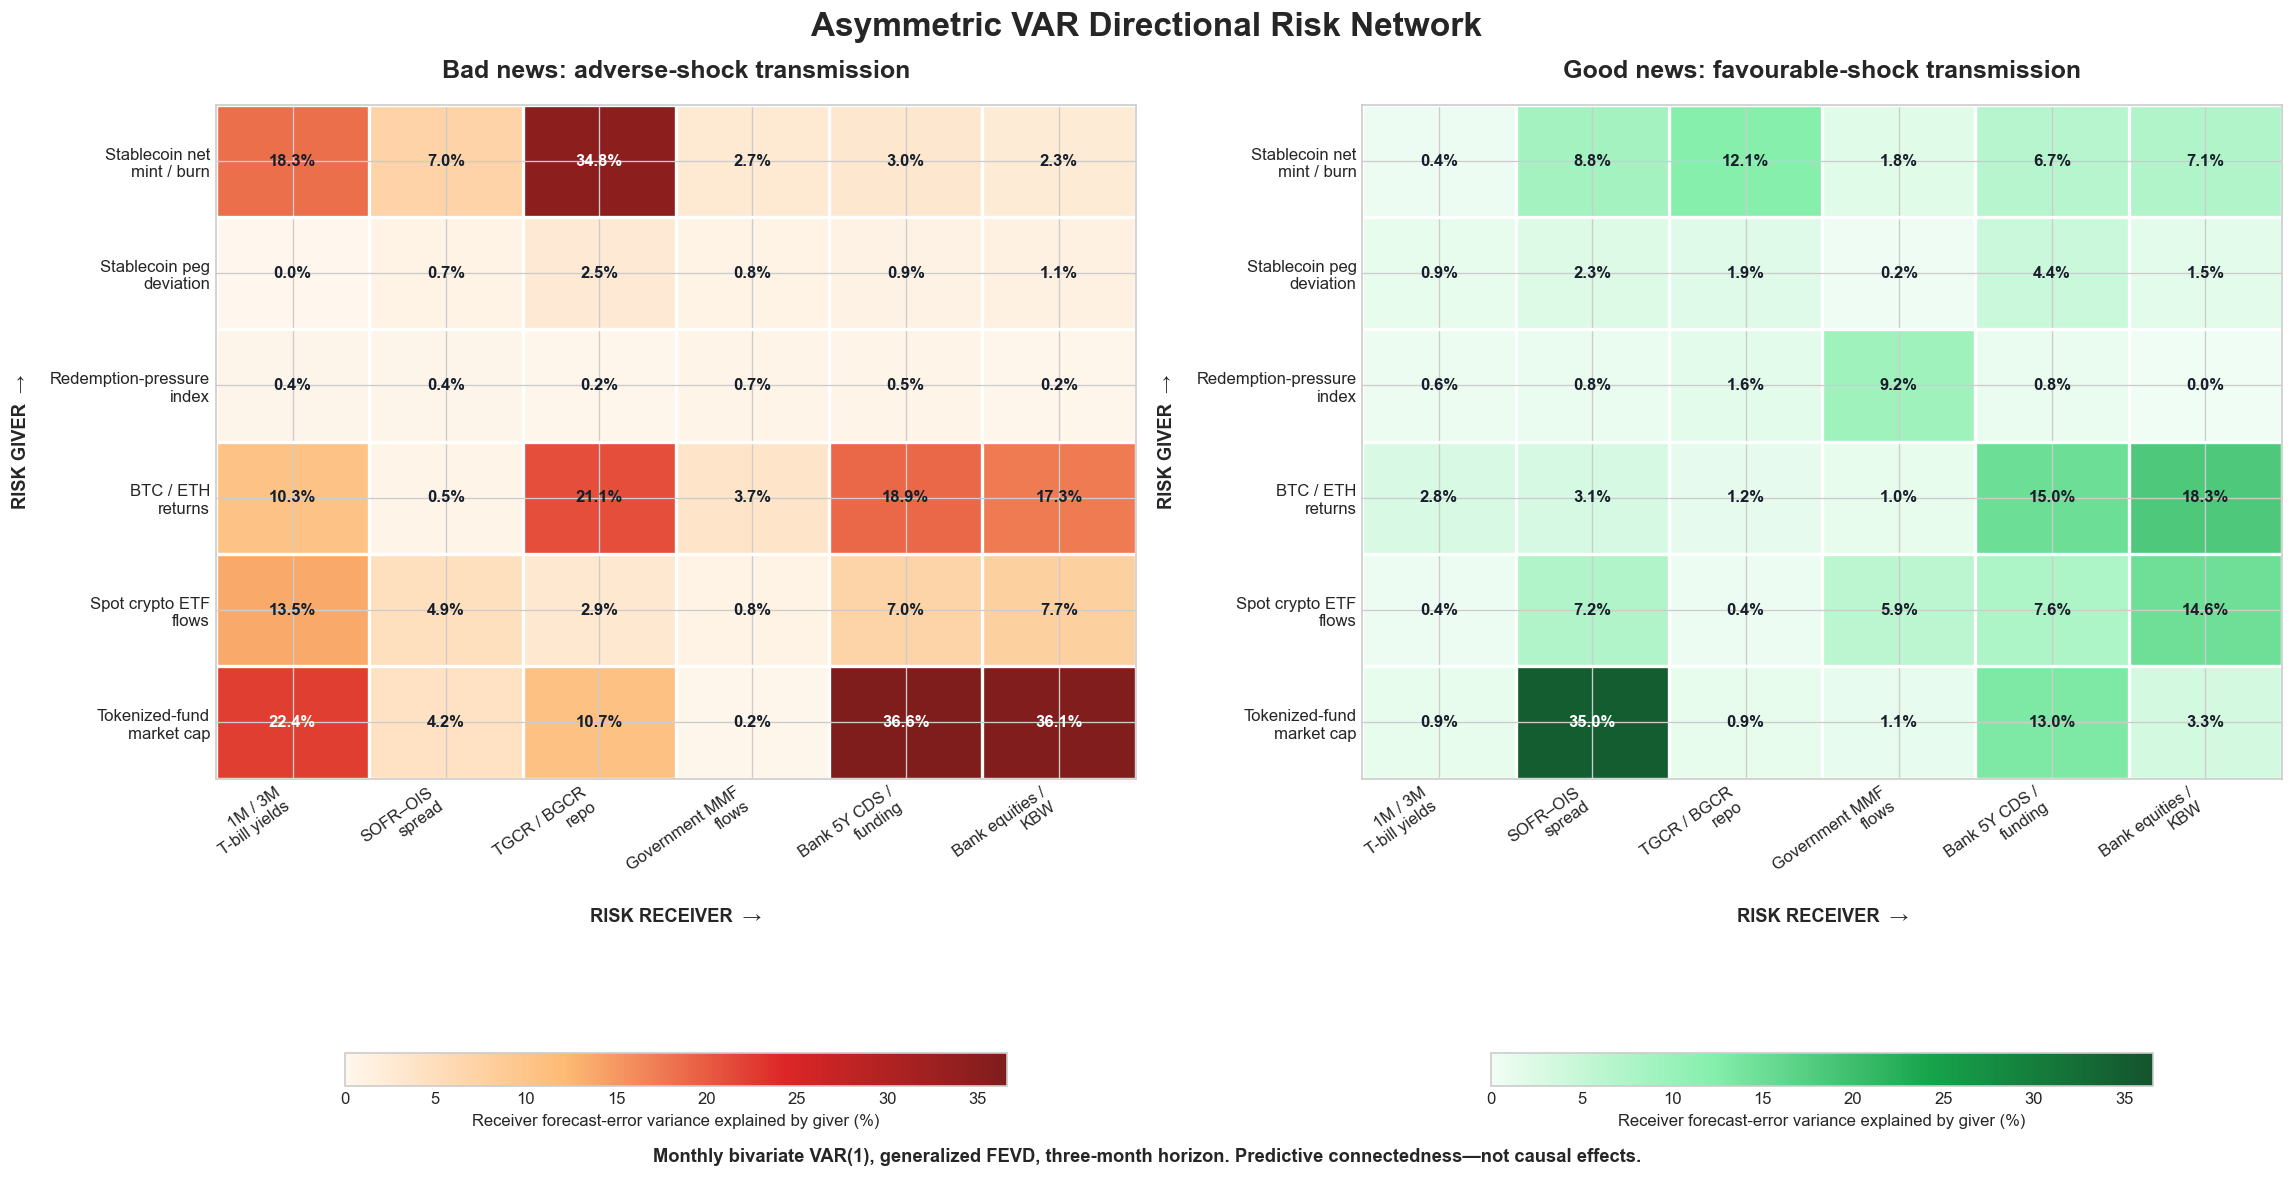

Saved figure to VAR_Network_Output/VAR_Directional_Risk_Network.png


In [5]:
giver_labels = [
    'Stablecoin net\nmint / burn',
    'Stablecoin peg\ndeviation',
    'Redemption-pressure\nindex',
    'BTC / ETH\nreturns',
    'Spot crypto ETF\nflows',
    'Tokenized-fund\nmarket cap',
]
receiver_labels = [
    '1M / 3M\nT-bill yields',
    'SOFR–OIS\nspread',
    'TGCR / BGCR\nrepo',
    'Government MMF\nflows',
    'Bank 5Y CDS /\nfunding',
    'Bank equities /\nKBW',
]
red_scale = LinearSegmentedColormap.from_list('bad_news', ['#fff7ed', '#fdba74', '#dc2626', '#7f1d1d'])
green_scale = LinearSegmentedColormap.from_list('good_news', ['#f0fdf4', '#86efac', '#16a34a', '#14532d'])
shared_maximum = np.nanmax([bad_news_matrix.to_numpy(), good_news_matrix.to_numpy()])

fig, axes = plt.subplots(1, 2, figsize=(19, 9), constrained_layout=True)
for axis, matrix, title, colour_map in [
    (axes[0], bad_news_matrix, 'Bad news: adverse-shock transmission', red_scale),
    (axes[1], good_news_matrix, 'Good news: favourable-shock transmission', green_scale),
]:
    image = axis.imshow(matrix.to_numpy(), cmap=colour_map, vmin=0, vmax=shared_maximum, aspect='auto')
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix.iloc[row, column]
            colour = 'white' if value > shared_maximum * 0.58 else '#17202a'
            axis.text(column, row, f'{value:.1f}%', ha='center', va='center', color=colour, fontsize=10, fontweight='bold')
    axis.set_xticks(np.arange(len(receiver_labels)), labels=receiver_labels, rotation=35, ha='right')
    axis.set_yticks(np.arange(len(giver_labels)), labels=giver_labels)
    axis.set_xlabel('RISK RECEIVER  →', fontsize=11, fontweight='bold', labelpad=12)
    axis.set_ylabel('RISK GIVER  →', fontsize=11, fontweight='bold', labelpad=12)
    axis.set_title(title, fontsize=15, pad=16)
    axis.set_xticks(np.arange(-0.5, len(receiver_labels), 1), minor=True)
    axis.set_yticks(np.arange(-0.5, len(giver_labels), 1), minor=True)
    axis.grid(which='minor', color='white', linewidth=2)
    axis.tick_params(which='minor', bottom=False, left=False)

bad_bar = fig.colorbar(axes[0].images[0], ax=axes[0], orientation='horizontal', shrink=.72, pad=.16)
bad_bar.set_label('Receiver forecast-error variance explained by giver (%)')
good_bar = fig.colorbar(axes[1].images[0], ax=axes[1], orientation='horizontal', shrink=.72, pad=.16)
good_bar.set_label('Receiver forecast-error variance explained by giver (%)')
fig.suptitle('Asymmetric VAR Directional Risk Network', fontsize=20, fontweight='bold', y=1.04)
fig.text(.5, -.025, 'Monthly bivariate VAR(1), generalized FEVD, three-month horizon. Predictive connectedness—not causal effects.', ha='center', fontsize=11, fontweight='bold')
figure_path = OUTPUT_FOLDER / 'VAR_Directional_Risk_Network.png'
fig.savefig(figure_path, dpi=220, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved figure to {figure_path}')

## 5. Pairwise sample sizes and asymmetry

The sample-size table is important because newer ETF and tokenized-fund series have shorter histories. Positive asymmetry means the bad-news spillover estimate exceeds the good-news estimate.

In [6]:
asymmetry = bad_news_matrix - good_news_matrix
asymmetry.to_csv(OUTPUT_FOLDER / 'VAR_Bad_Minus_Good_Asymmetry.csv')
display(pd.concat(
    {'Bad news (%)': bad_news_matrix.round(2), 'Good news (%)': good_news_matrix.round(2), 'Bad minus good (pp)': asymmetry.round(2)},
    axis=1,
))
display(pairwise_observations.astype('Int64').style.set_caption('Common monthly observations used by each pair'))

Bad news (%)                                 \
                          1M/3M T-bill yields SOFR-OIS spread TGCR/BGCR repo   
Stablecoin net mint/burn                18.32            7.01          34.78   
Stablecoin peg deviation                 0.03            0.74           2.55   
Redemption-pressure index                0.41            0.41           0.21   
BTC/ETH returns                         10.33            0.51          21.14   
Spot crypto ETF flows                   13.47            4.85           2.90   
Tokenized-fund market cap               22.42            4.18          10.65   

                                                                    \
                          Government MMF flows Bank 5Y CDS/funding   
Stablecoin net mint/burn                  2.71                3.04   
Stablecoin peg deviation                  0.77                0.94   
Redemption-pressure index                 0.65                0.51   
BTC/ETH returns                           3.67               18.93   
Spot crypto ETF flows                     0.82                6.99   
Tokenized-fund market cap                 0.22               36.61   

                                                  Good news (%)  \
                          Bank equities/KBW 1M/3M T-bill yields   
Stablecoin net mint/burn               2.30                0.41   
Stablecoin peg deviation               1.15                0.94   
Redemption-pressure index              0.20                0.55   
BTC/ETH returns                       17.34                2.83   
Spot crypto ETF flows                  7.72                0.38   
Tokenized-fund market cap             36.15                0.94   

                                                                               \
                          SOFR-OIS spread TGCR/BGCR repo Government MMF flows   
Stablecoin net mint/burn             8.83          12.08                 1.78   
Stablecoin peg deviation             2.34           1.92                 0.18   
Redemption-pressure index            0.78           1.56                 9.21   
BTC/ETH returns                      3.10           1.20                 0.98   
Spot crypto ETF flows                7.21           0.40                 5.94   
Tokenized-fund market cap           34.99           0.91                 1.11   

                                                                 \
                          Bank 5Y CDS/funding Bank equities/KBW   
Stablecoin net mint/burn                 6.67              7.15   
Stablecoin peg deviation                 4.42              1.55   
Redemption-pressure index                0.81              0.01   
BTC/ETH returns                         14.98             18.28   
Spot crypto ETF flows                    7.61             14.63   
Tokenized-fund market cap               13.02              3.28   

                          Bad minus good (pp)                                 \
                          1M/3M T-bill yields SOFR-OIS spread TGCR/BGCR repo   
Stablecoin net mint/burn                17.91           -1.82          22.70   
Stablecoin peg deviation                -0.91           -1.60           0.63   
Redemption-pressure index               -0.14           -0.37          -1.35   
BTC/ETH returns                          7.50           -2.60          19.94   
Spot crypto ETF flows                   13.09           -2.36           2.50   
Tokenized-fund market cap               21.48          -30.81           9.74   

                                                                    \
                          Government MMF flows Bank 5Y CDS/funding   
Stablecoin net mint/burn                  0.93               -3.63   
Stablecoin peg deviation                  0.59               -3.48   
Redemption-pressure index                -8.55               -0.30   
BTC/ETH returns                           2.70                3.95   
Spot crypto ETF flows                    -5.13 

,1M/3M T-bill yields,SOFR-OIS spread,TGCR/BGCR repo,Government MMF flows,Bank 5Y CDS/funding,Bank equities/KBW
Stablecoin net mint/burn,78,72,54,78,78,78
Stablecoin peg deviation,78,72,54,77,78,78
Redemption-pressure index,78,72,54,77,78,78
BTC/ETH returns,78,72,54,78,78,78
Spot crypto ETF flows,31,31,31,30,31,31
Tokenized-fund market cap,53,53,53,52,53,53


## 6. Directional graph representation

This bipartite graph shows the ten strongest estimated links in each regime. Giver nodes are on the left, receiver nodes are on the right, arrow direction is giver → receiver, and edge thickness represents the generalized FEVD percentage.

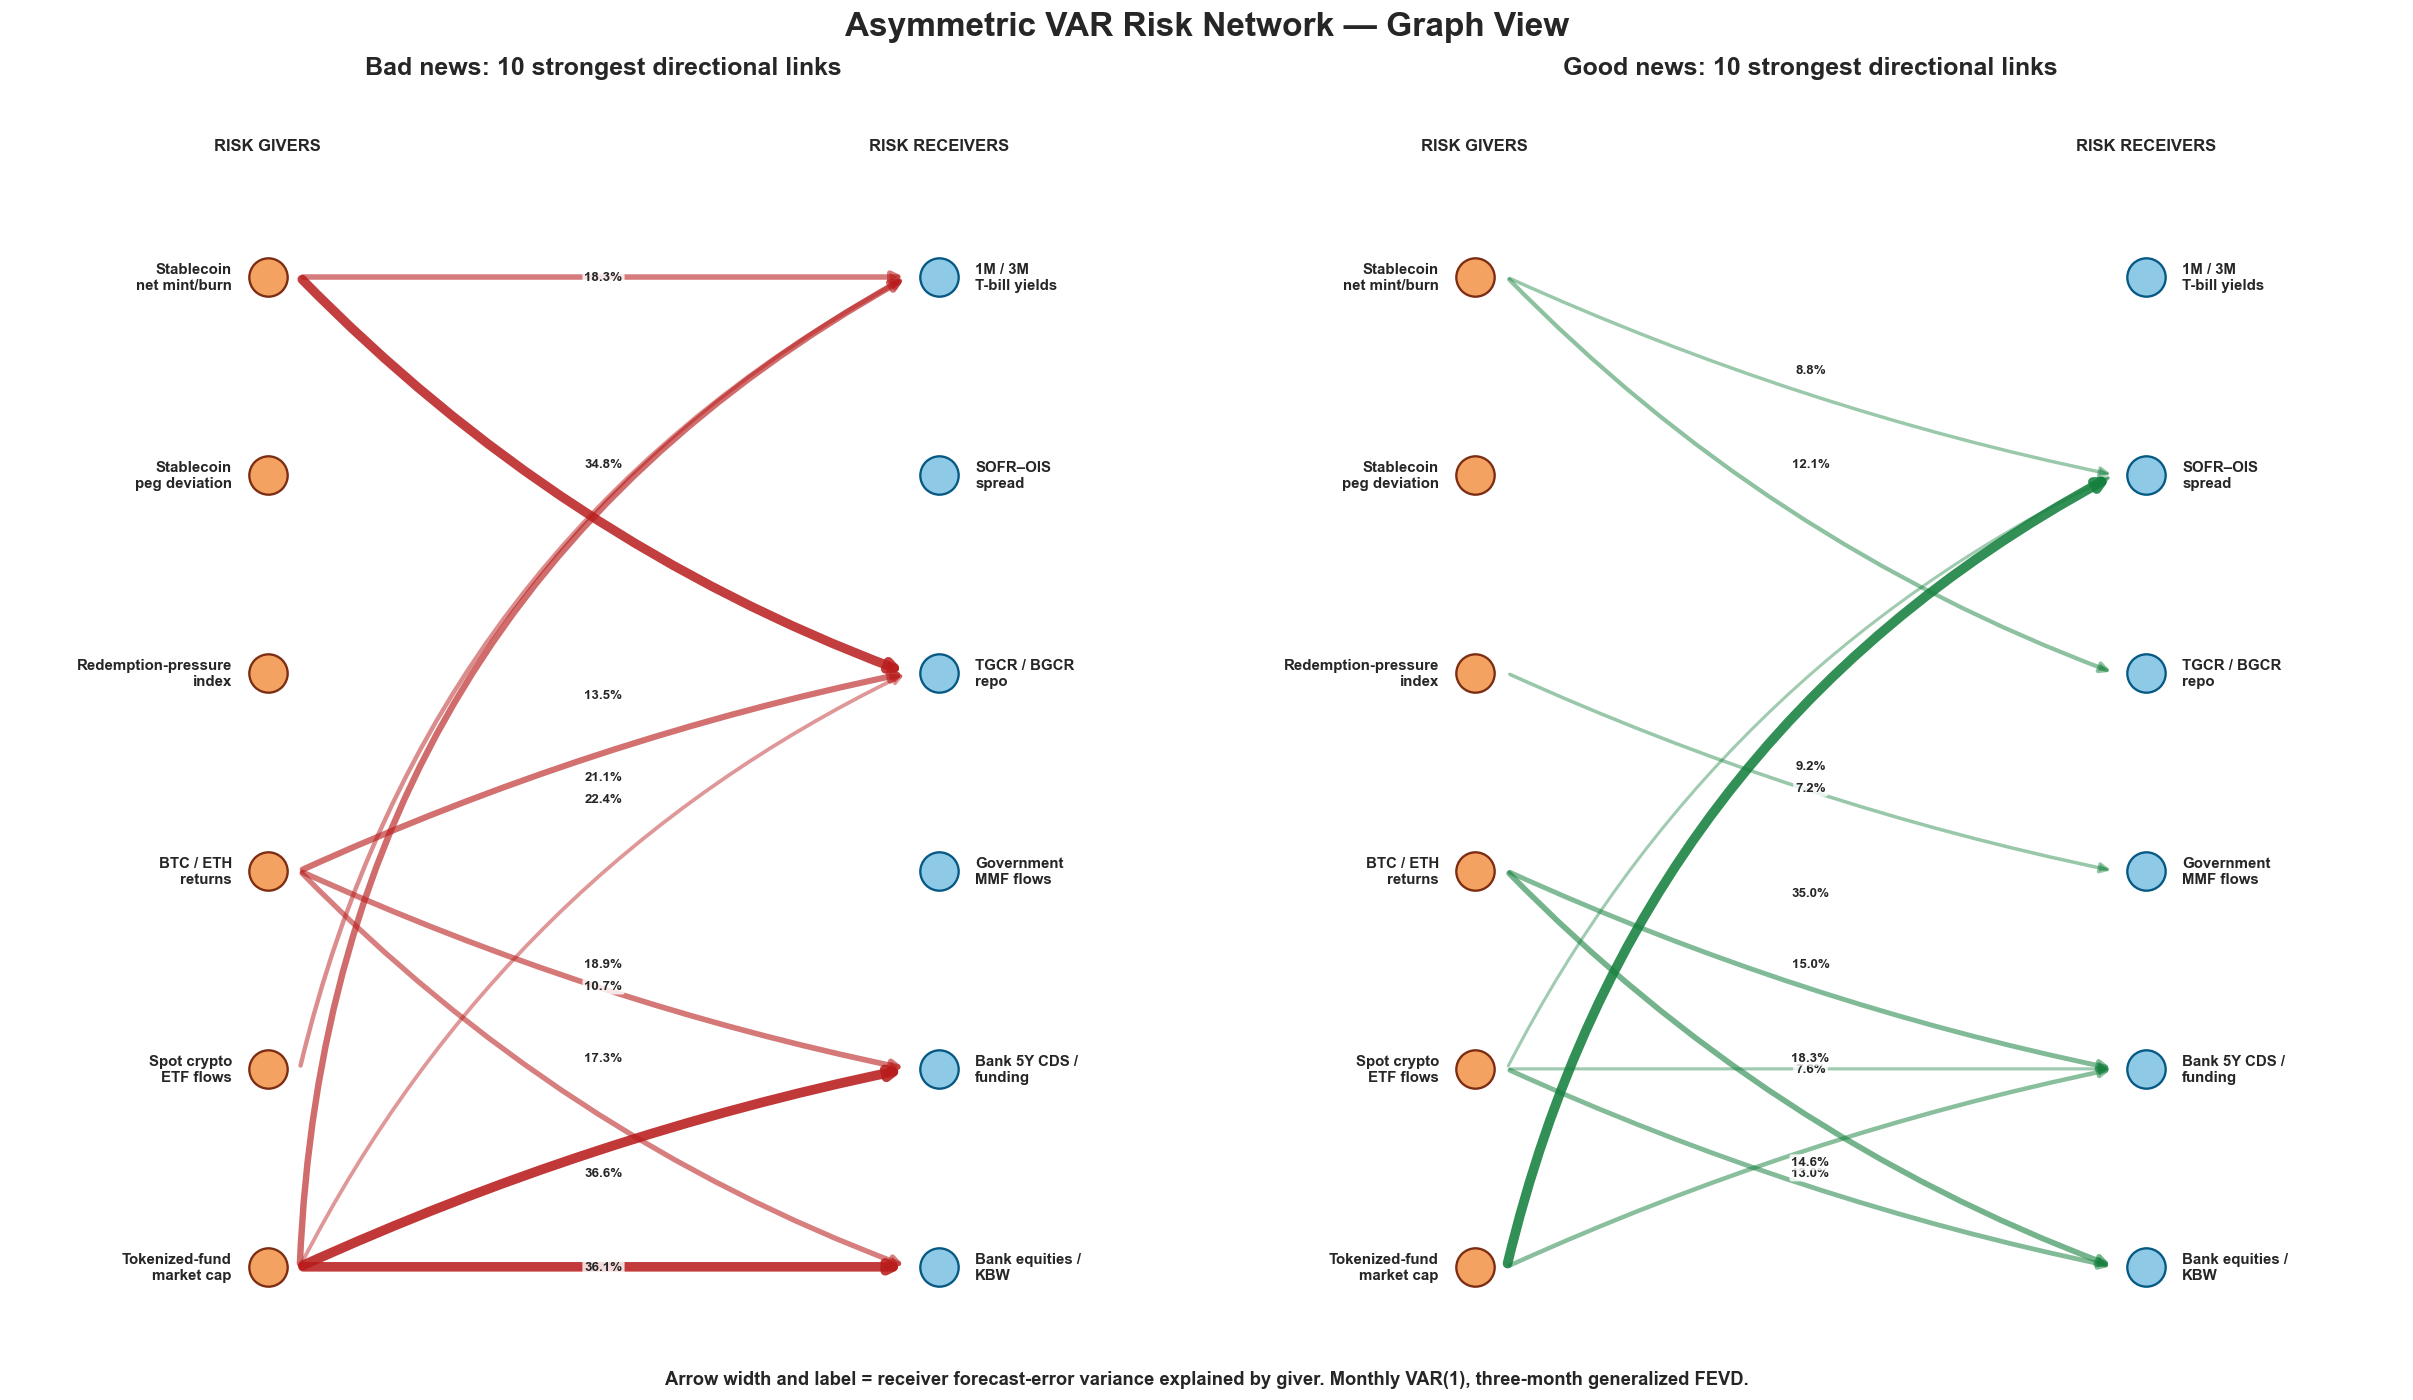

Saved graph to VAR_Network_Output/VAR_Directional_Risk_Graph.png


In [7]:
from matplotlib.patches import FancyArrowPatch

short_giver_labels = {
    'Stablecoin net mint/burn': 'Stablecoin\nnet mint/burn',
    'Stablecoin peg deviation': 'Stablecoin\npeg deviation',
    'Redemption-pressure index': 'Redemption-pressure\nindex',
    'BTC/ETH returns': 'BTC / ETH\nreturns',
    'Spot crypto ETF flows': 'Spot crypto\nETF flows',
    'Tokenized-fund market cap': 'Tokenized-fund\nmarket cap',
}
short_receiver_labels = {
    '1M/3M T-bill yields': '1M / 3M\nT-bill yields',
    'SOFR-OIS spread': 'SOFR–OIS\nspread',
    'TGCR/BGCR repo': 'TGCR / BGCR\nrepo',
    'Government MMF flows': 'Government\nMMF flows',
    'Bank 5Y CDS/funding': 'Bank 5Y CDS /\nfunding',
    'Bank equities/KBW': 'Bank equities /\nKBW',
}

def draw_directional_graph(axis, matrix, title, edge_colour, strongest_links=10):
    giver_names = list(matrix.index)
    receiver_names = list(matrix.columns)
    giver_y = dict(zip(giver_names, np.linspace(0.90, 0.10, len(giver_names))))
    receiver_y = dict(zip(receiver_names, np.linspace(0.90, 0.10, len(receiver_names))))

    edges = [
        (matrix.loc[giver, receiver], giver, receiver)
        for giver in giver_names for receiver in receiver_names
        if pd.notna(matrix.loc[giver, receiver])
    ]
    edges = sorted(edges, reverse=True)[:strongest_links]
    maximum = max(value for value, _, _ in edges)

    for value, giver, receiver in sorted(edges):
        y_start = giver_y[giver]
        y_end = receiver_y[receiver]
        curvature = np.clip((y_start - y_end) * 0.35, -0.30, 0.30)
        arrow = FancyArrowPatch(
            (0.12, y_start), (0.88, y_end),
            connectionstyle=f'arc3,rad={curvature}',
            arrowstyle='-|>', mutation_scale=12,
            linewidth=0.8 + 5.0 * value / maximum,
            color=edge_colour, alpha=0.28 + 0.60 * value / maximum,
            zorder=1,
        )
        axis.add_patch(arrow)
        label_y = (y_start + y_end) / 2 + curvature * 0.08
        axis.text(
            0.50, label_y, f'{value:.1f}%',
            ha='center', va='center', fontsize=8, fontweight='bold', zorder=4,
            bbox={'boxstyle': 'round,pad=0.15', 'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.82},
        )

    for giver, y_position in giver_y.items():
        axis.scatter(0.08, y_position, s=530, color='#f4a261', edgecolor='#7c2d12', linewidth=1.4, zorder=5)
        axis.text(0.035, y_position, short_giver_labels[giver], ha='right', va='center', fontsize=9, fontweight='bold')
    for receiver, y_position in receiver_y.items():
        axis.scatter(0.92, y_position, s=530, color='#8ecae6', edgecolor='#075985', linewidth=1.4, zorder=5)
        axis.text(0.965, y_position, short_receiver_labels[receiver], ha='left', va='center', fontsize=9, fontweight='bold')

    axis.text(0.08, 1.00, 'RISK GIVERS', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axis.text(0.92, 1.00, 'RISK RECEIVERS', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axis.set_title(title, fontsize=15, pad=18)
    axis.set_xlim(-0.24, 1.24)
    axis.set_ylim(0.02, 1.04)
    axis.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(20, 11), constrained_layout=True)
draw_directional_graph(axes[0], bad_news_matrix, 'Bad news: 10 strongest directional links', '#b91c1c')
draw_directional_graph(axes[1], good_news_matrix, 'Good news: 10 strongest directional links', '#15803d')
fig.suptitle('Asymmetric VAR Risk Network — Graph View', fontsize=20, fontweight='bold', y=1.03)
fig.text(0.5, -0.01, 'Arrow width and label = receiver forecast-error variance explained by giver. Monthly VAR(1), three-month generalized FEVD.', ha='center', fontsize=11, fontweight='bold')
graph_path = OUTPUT_FOLDER / 'VAR_Directional_Risk_Graph.png'
fig.savefig(graph_path, dpi=220, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved graph to {graph_path}')

## Interpretation limits

- A large cell means the giver improves prediction of the receiver's forecast-error variance within that pair; it does not prove structural causation.
- The pairwise design avoids discarding long histories, but each cell can use a different start date.
- Monthly aggregation is necessary because government-MMF data are monthly.
- Results are sensitive to signal definitions, lag order, horizon, revisions, and the short ETF/tokenized-fund samples. Treat this dashboard as an exploratory first-pass network for subsequent robustness testing or a full TVP-VAR.